In [1]:
from ipyleaflet import Map, DrawControl
import json
import geopandas as gpd


In [5]:
# Create a map
m = Map(center=(-25.2744, 133.7751), zoom=4)

# Add draw control
draw_control = DrawControl()
draw_control.polyline = {}
draw_control.circle = {}
draw_control.rectangle = {}

# A variable to store the GeoJSON data
drawn_features = []

# Callback to handle drawn features
def handle_draw(self, action, geo_json):
    print("Geometry drawn:", geo_json)
    drawn_features.append(geo_json)  # Save the GeoJSON to a list

    # Save to a GeoJSON file immediately (optional)
    with open('drawn_polygon.geojson', 'w') as f:
        json.dump(geo_json, f)
    print("Saved to 'drawn_polygon.geojson'.")

draw_control.on_draw(handle_draw)
m.add_control(draw_control)

# Display the map
m

Map(center=[-25.2744, 133.7751], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

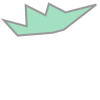

In [6]:
poly = gpd.read_file("drawn_polygon.geojson")
poly.geometry[0]

In [7]:
print(poly.crs)

EPSG:4326


In [8]:
# Reproject to EPSG:3577 (GDA94 / Australian Albers)
poly_3577 = poly.to_crs(epsg=3577)

In [9]:
print(poly_3577.crs)

EPSG:3577
